# Machine learning guide


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle

In [2]:
df = pd.read_csv("house_prices.csv")

In [3]:
df.head()

,HouseID,Location,Bedrooms,Bathrooms,SquareFeet,Price
0,1,Chicago,1,2,1928,469558
1,2,Chicago,2,1,1093,313063
2,3,New York,3,1,2100,571116
3,4,Chicago,4,2,2456,609514
4,5,Los Angeles,4,2,1524,475262


In [4]:
df.isnull().sum()

HouseID       0
Location      0
Bedrooms      0
Bathrooms     0
SquareFeet    0
Price         0
dtype: int64

In [5]:
df["Location"].unique()

array(['Chicago', 'New York', 'Los Angeles', 'Houston'], dtype=object)

In [6]:
df["Location"] = df["Location"].replace({
    "Chicago":"Noida",
    "New York":"Gurugram",
    "Los Angeles":"Mumbai",
    "Houston":"Delhi"})

In [7]:
df.head()

,HouseID,Location,Bedrooms,Bathrooms,SquareFeet,Price
0,1,Noida,1,2,1928,469558
1,2,Noida,2,1,1093,313063
2,3,Gurugram,3,1,2100,571116
3,4,Noida,4,2,2456,609514
4,5,Mumbai,4,2,1524,475262


In [8]:
x= df[["SquareFeet","Bedrooms","Bathrooms"]]
y= df["Price"]



In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression


In [12]:
lr = LinearRegression()

In [13]:
lr.fit(X_train,y_train)

LinearRegression()

In [14]:
y_pred = lr.predict(X_test)

In [15]:
from sklearn.metrics import r2_score

In [16]:
r2 = r2_score(y_test,y_pred)

In [17]:
r2

0.9663664820775998

In [18]:
m=lr.coef_

In [19]:
c=lr.intercept_

In [20]:
m*4.0+c

array([ 97457.54426672, 145863.8404573 , 172114.97225032])

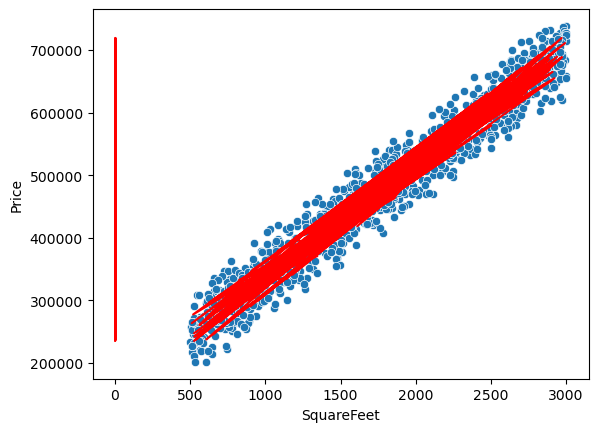

In [28]:
sns.scatterplot(x = 'SquareFeet',  y = 'Price' , data = df)

plt.plot(X_test , lr.predict(X_test) , color = 'red')

In [34]:
pickle.dump(lr, open("model.pkl", "wb"))